# Uber Ride Exploratory Data Analysis & Visualization

#### Import necessary packages

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
import datetime
from datetime import datetime
from datetime import timedelta
import h3

In [2]:
df = pd.read_csv('Analyst_dataset.csv')

## Initial Data Exploration

In [3]:
df.head(5)

,trip_id,customer_id,timestamp,pick_lat,pick_lng,drop_lat,drop_lng,travel_distance,travel_time,trip_fare
0,ID001,CUST_001,1546709270211,17.442705,78.387878,17.457829,78.399056,2.806,12.609667,37
1,ID002,CUST_002,1546709309524,17.490189,78.415512,17.450548,78.367294,11.991,24.075200,119
2,ID003,CUST_003,1546709331857,17.370108,78.515045,17.377041,78.517921,1.322,8.708300,27
3,ID004,CUST_004,1546709358403,17.439314,78.443001,17.397131,78.516586,11.822,24.037550,121
4,ID005,CUST_005,1546709386884,17.432325,78.381966,17.401625,78.400032,6.978,16.120867,58


In [4]:
df.tail(5)

,trip_id,customer_id,timestamp,pick_lat,pick_lng,drop_lat,drop_lng,travel_distance,travel_time,trip_fare
44582,ID44583,CUST_19137,1546531491044,17.443661,78.391968,17.451042,78.371658,5.665,12.573883,55
44583,ID44584,CUST_19138,1546531505869,17.439289,78.396118,17.449976,78.389160,9.292,17.937717,76
44584,ID44585,CUST_5061,1546531522103,17.363689,78.535194,17.374418,78.529823,5.485,17.403850,55
44585,ID44586,CUST_19139,1546531536429,17.401539,78.570076,17.416904,78.591362,2.326,14.236767,35
44586,ID44587,CUST_15562,1546531549938,17.385243,78.479896,17.394102,78.499550,3.204,7.085400,37


In [5]:
df.shape

(44587, 10)

In [6]:
df.size

445870

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 44587 entries, 0 to 44586
Data columns (total 10 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   trip_id          44587 non-null  object 
 1   customer_id      44587 non-null  object 
 2   timestamp        44587 non-null  int64  
 3   pick_lat         44587 non-null  float64
 4   pick_lng         44587 non-null  float64
 5   drop_lat         44587 non-null  float64
 6   drop_lng         44587 non-null  float64
 7   travel_distance  44587 non-null  float64
 8   travel_time      44587 non-null  float64
 9   trip_fare        44587 non-null  int64  
dtypes: float64(6), int64(2), object(2)
memory usage: 3.4+ MB


In [8]:
df.describe()

,timestamp,pick_lat,pick_lng,drop_lat,drop_lng,travel_distance,travel_time,trip_fare
count,4.458700e+04,44587.000000,44587.000000,44587.000000,44587.000000,44587.000000,44587.000000,44587.000000
mean,1.546632e+12,17.427919,78.435542,17.427891,78.434897,5.094359,15.819835,53.872833
std,1.518684e+08,0.030049,0.053333,0.037722,0.054965,3.365008,23.462865,33.430462
min,1.546368e+12,17.330339,78.308258,12.921696,77.548103,-1.000000,0.022750,20.000000
25%,1.546503e+12,17.405327,78.386562,17.405660,78.385010,2.744500,8.428525,36.000000
50%,1.546611e+12,17.432136,78.438866,17.431213,78.438164,4.299000,13.126250,46.000000
75%,1.546772e+12,17.446777,78.480839,17.446907,78.480255,6.679500,20.111167,60.000000
max,1.546886e+12,17.529791,78.600647,17.736155,78.634804,52.801000,4134.388700,1670.000000


## Data Cleaning & Preprocessing

In [9]:
df.isnull().values.any()

False

In [10]:
df.isnull().values.any().sum()

0

In [11]:
df.describe()

,timestamp,pick_lat,pick_lng,drop_lat,drop_lng,travel_distance,travel_time,trip_fare
count,4.458700e+04,44587.000000,44587.000000,44587.000000,44587.000000,44587.000000,44587.000000,44587.000000
mean,1.546632e+12,17.427919,78.435542,17.427891,78.434897,5.094359,15.819835,53.872833
std,1.518684e+08,0.030049,0.053333,0.037722,0.054965,3.365008,23.462865,33.430462
min,1.546368e+12,17.330339,78.308258,12.921696,77.548103,-1.000000,0.022750,20.000000
25%,1.546503e+12,17.405327,78.386562,17.405660,78.385010,2.744500,8.428525,36.000000
50%,1.546611e+12,17.432136,78.438866,17.431213,78.438164,4.299000,13.126250,46.000000
75%,1.546772e+12,17.446777,78.480839,17.446907,78.480255,6.679500,20.111167,60.000000
max,1.546886e+12,17.529791,78.600647,17.736155,78.634804,52.801000,4134.388700,1670.000000


***

### Assumptions Made During Cleaning

1. There are customer IDs with negative travel_distance which will be removed assuming it as an error.
2. There are customer IDs with travel_distance as 0, which might result from trip cancellations, for which a minimum fare of Rs. 20 is charged.

In [12]:
df_zero_negative = df[df['travel_distance'] <= 0]

In [13]:
df_zero_negative 

,trip_id,customer_id,timestamp,pick_lat,pick_lng,drop_lat,drop_lng,travel_distance,travel_time,trip_fare
55,ID056,CUST_056,1546710133113,17.409777,78.462952,17.409777,78.462952,0.0,0.052050,20
145,ID146,CUST_142,1546712267334,17.396492,78.479980,17.368525,78.533218,-1.0,19.247367,959
152,ID153,CUST_149,1546712538963,17.385977,78.431549,17.385977,78.431549,0.0,0.242750,20
155,ID156,CUST_152,1546712580519,17.426565,78.452843,17.426565,78.452843,0.0,0.261333,20
249,ID250,CUST_243,1546532267170,17.438530,78.394989,17.468258,78.360641,0.0,0.101450,20
...,...,...,...,...,...,...,...,...,...,...
43381,ID43382,CUST_18925,1546523595626,17.389580,78.498840,17.398024,78.497429,0.0,0.482500,20
43668,ID43669,CUST_948,1546525291171,17.440626,78.375298,17.434677,78.368263,0.0,0.215783,20
44137,ID44138,CUST_19053,1546528214931,17.450041,78.421425,17.432915,78.407387,0.0,0.152283,20
44138,ID44139,CUST_19054,1546528220149,17.434318,78.404221,17.436552,78.433281,0.0,0.695067,20


In [14]:
# Taking the actual data by removing errors
df = df[df['travel_distance'] > 0]

In [15]:
# Changing epoch time to datetime
df['timestamp'] = df['timestamp'].apply(lambda x: datetime.fromtimestamp(x/1000))

In [16]:
df

,trip_id,customer_id,timestamp,pick_lat,pick_lng,drop_lat,drop_lng,travel_distance,travel_time,trip_fare
0,ID001,CUST_001,2019-01-05 22:57:50.211,17.442705,78.387878,17.457829,78.399056,2.806,12.609667,37
1,ID002,CUST_002,2019-01-05 22:58:29.524,17.490189,78.415512,17.450548,78.367294,11.991,24.075200,119
2,ID003,CUST_003,2019-01-05 22:58:51.857,17.370108,78.515045,17.377041,78.517921,1.322,8.708300,27
3,ID004,CUST_004,2019-01-05 22:59:18.403,17.439314,78.443001,17.397131,78.516586,11.822,24.037550,121
4,ID005,CUST_005,2019-01-05 22:59:46.884,17.432325,78.381966,17.401625,78.400032,6.978,16.120867,58
...,...,...,...,...,...,...,...,...,...,...
44582,ID44583,CUST_19137,2019-01-03 21:34:51.044,17.443661,78.391968,17.451042,78.371658,5.665,12.573883,55
44583,ID44584,CUST_19138,2019-01-03 21:35:05.869,17.439289,78.396118,17.449976,78.389160,9.292,17.937717,76
44584,ID44585,CUST_5061,2019-01-03 21:35:22.103,17.363689,78.535194,17.374418,78.529823,5.485,17.403850,55
44585,ID44586,CUST_19139,2019-01-03 21:35:36.429,17.401539,78.570076,17.416904,78.591362,2.326,14.236767,35


In [17]:
df['date']=df['timestamp'].dt.date

In [18]:
df['hour']=df['timestamp'].dt.hour

In [19]:
df

,trip_id,customer_id,timestamp,pick_lat,pick_lng,drop_lat,drop_lng,travel_distance,travel_time,trip_fare,date,hour
0,ID001,CUST_001,2019-01-05 22:57:50.211,17.442705,78.387878,17.457829,78.399056,2.806,12.609667,37,2019-01-05,22
1,ID002,CUST_002,2019-01-05 22:58:29.524,17.490189,78.415512,17.450548,78.367294,11.991,24.075200,119,2019-01-05,22
2,ID003,CUST_003,2019-01-05 22:58:51.857,17.370108,78.515045,17.377041,78.517921,1.322,8.708300,27,2019-01-05,22
3,ID004,CUST_004,2019-01-05 22:59:18.403,17.439314,78.443001,17.397131,78.516586,11.822,24.037550,121,2019-01-05,22
4,ID005,CUST_005,2019-01-05 22:59:46.884,17.432325,78.381966,17.401625,78.400032,6.978,16.120867,58,2019-01-05,22
...,...,...,...,...,...,...,...,...,...,...,...,...
44582,ID44583,CUST_19137,2019-01-03 21:34:51.044,17.443661,78.391968,17.451042,78.371658,5.665,12.573883,55,2019-01-03,21
44583,ID44584,CUST_19138,2019-01-03 21:35:05.869,17.439289,78.396118,17.449976,78.389160,9.292,17.937717,76,2019-01-03,21
44584,ID44585,CUST_5061,2019-01-03 21:35:22.103,17.363689,78.535194,17.374418,78.529823,5.485,17.403850,55,2019-01-03,21
44585,ID44586,CUST_19139,2019-01-03 21:35:36.429,17.401539,78.570076,17.416904,78.591362,2.326,14.236767,35,2019-01-03,21


***

## Exploratory Data Analysis (EDA)

### Top 10 Customers by Total Trip Fare

In [20]:
customer_totals = df.groupby('customer_id')['trip_fare'].sum()
top_customers_bases_on_fare = customer_totals.nlargest(10)
print("Top 10 Customers based on Overall Trip Fare:")
pd.DataFrame(top_customers_bases_on_fare)

Top 10 Customers based on Overall Trip Fare:


,trip_fare
customer_id,
CUST_345,2399
CUST_4119,2203
CUST_004,1841
CUST_279,1811
CUST_18770,1670
CUST_2367,1361
CUST_6154,1354
CUST_6124,1332
CUST_232,1281


***

### Daily Ride Count

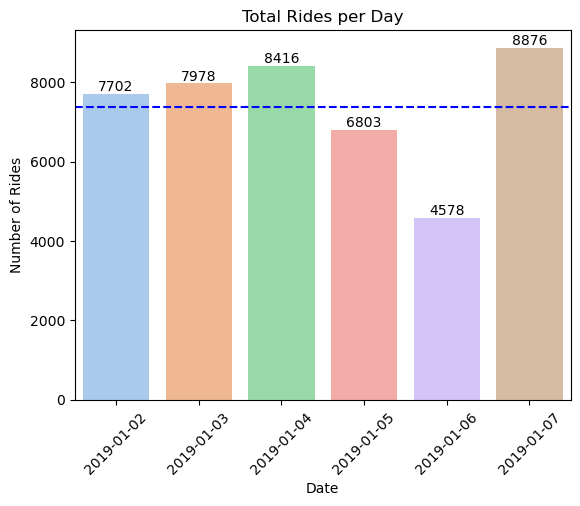

In [21]:
ride_counts = df['date'].value_counts().sort_index()
average_rides = ride_counts.mean()
order = ride_counts.index.sort_values(ascending=True)
a = sns.countplot(data=df, x='date', palette='pastel', order=order)
plt.xticks(rotation=45)

for bar in a.containers:
    a.bar_label(bar)

plt.axhline(y=average_rides, color='blue', linestyle='--', label='Average')
plt.xlabel('Date')
plt.ylabel('Number of Rides')
plt.title('Total Rides per Day')
plt.show()

In [22]:
##Average trips per day
average_rides = df.groupby('date')['trip_id'].count().mean()
print("Average trips per day:", average_rides)

Average trips per day: 7392.166666666667


***

### Hourly Ride Distribution

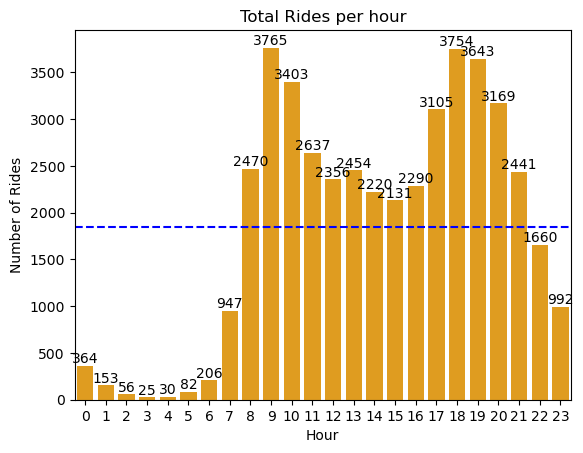

In [23]:
ride_counts = df['hour'].value_counts().sort_index()
average_rides = ride_counts.mean()
order = ride_counts.index.sort_values(ascending=True)
a = sns.countplot(data=df, x='hour', color='orange', order=order)
#plt.xticks(rotation=45)

for bar in a.containers:
    a.bar_label(bar)

plt.axhline(y=average_rides, color='blue', linestyle='--', label='Average')
plt.xlabel('Hour')
plt.ylabel('Number of Rides')
plt.title('Total Rides per hour')
plt.show()

In [24]:
df.columns

Index(['trip_id', 'customer_id', 'timestamp', 'pick_lat', 'pick_lng',
       'drop_lat', 'drop_lng', 'travel_distance', 'travel_time', 'trip_fare',
       'date', 'hour'],
      dtype='object')

***

### Hourly Average Speed Analysis

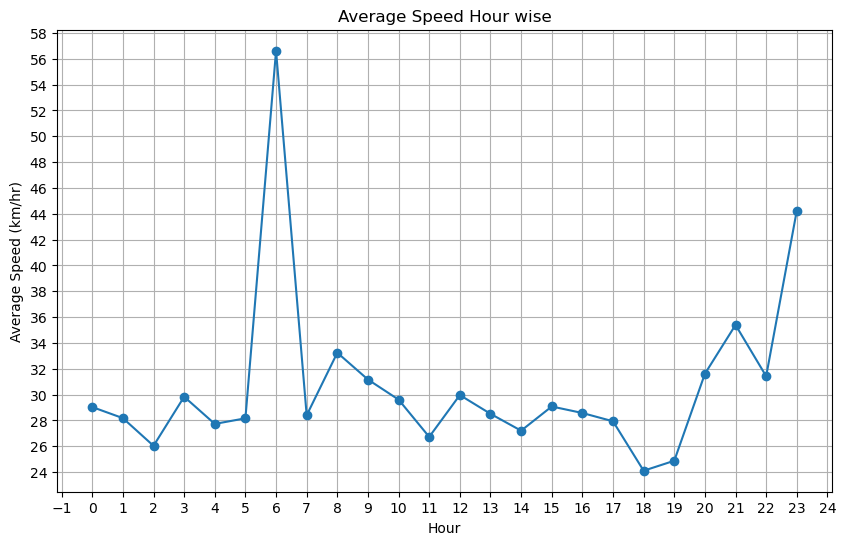

In [25]:
df['average_speed'] = df['travel_distance'] / (df['travel_time']/60)
average_speed_hourly = df.groupby('hour')['average_speed'].mean()
plt.figure(figsize=(10, 6))
plt.plot(average_speed_hourly.index, average_speed_hourly.values, marker='o')
plt.locator_params(axis='x', nbins=30) 
plt.locator_params(axis='y', nbins=20)
plt.xlabel('Hour')
plt.ylabel('Average Speed (km/hr)')
plt.title('Average Speed Hour wise')
plt.grid(True)
plt.show()

In [26]:
#Overall Average rides per customer

average_rides = df.groupby('customer_id').size().mean()
print("Overall Average rides per customer:", average_rides)

Overall Average rides per customer: 2.3247025525446827


***

### Travel Distance Distribution

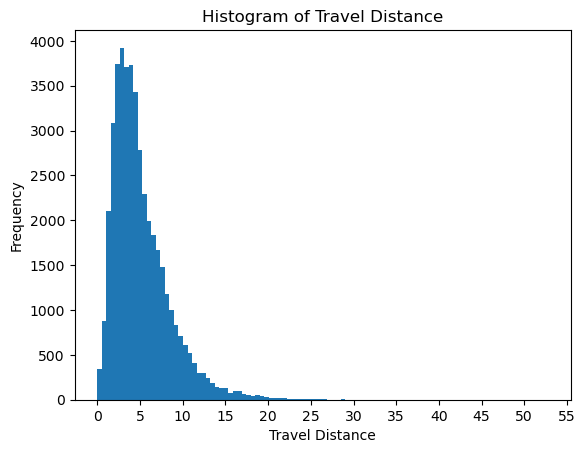

In [27]:
plt.hist(df['travel_distance'], bins=100)
plt.xlabel('Travel Distance')
plt.ylabel('Frequency')
plt.title('Histogram of Travel Distance')
plt.locator_params(axis='x', nbins=20) 

plt.show()

***

### Travel Distance vs Trip Fare (Scatter Plot)

Text(0.5, 1.0, 'Scatter Plot of Travel Distance vs. Trip Fare')

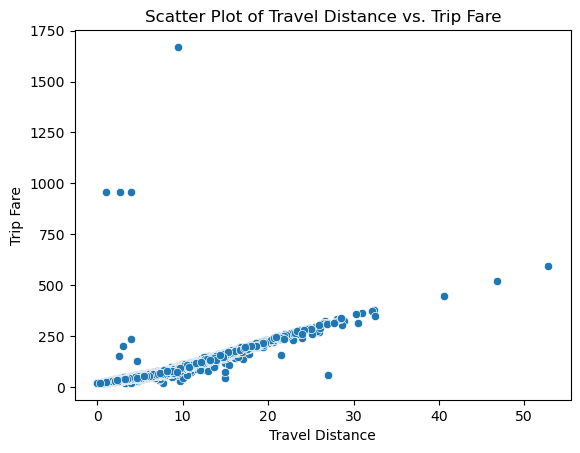

In [28]:
sns.scatterplot(x='travel_distance',y='trip_fare',data=df)
plt.xlabel('Travel Distance')
plt.ylabel('Trip Fare')
plt.title('Scatter Plot of Travel Distance vs. Trip Fare')

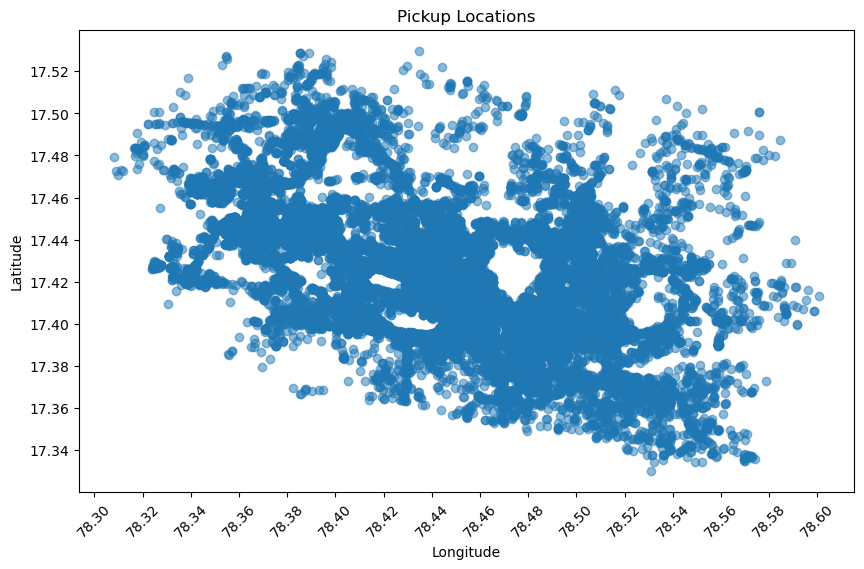

In [29]:
plt.figure(figsize=(10,6))
plt.scatter(df['pick_lng'], df['pick_lat'], alpha=0.5)
plt.locator_params(axis='x', nbins=20) 
plt.locator_params(axis='y', nbins=20)
plt.xticks(rotation=45)
plt.xlabel('Longitude')
plt.ylabel('Latitude')
plt.title('Pickup Locations')
plt.show()

***

In [30]:
#Top 10 Pick up locations
pickup_counts = df.groupby(['pick_lat', 'pick_lng']).size().reset_index(name='count')
sorted_pickups = pickup_counts.sort_values(by='count', ascending=False)
top_10_pickups = sorted_pickups.head(10)
print(top_10_pickups)

        pick_lat   pick_lng  count
43680  17.497129  78.386581      4
43673  17.497105  78.386574      3
23548  17.434418  78.500732      2
962    17.366550  78.551582      2
21360  17.430283  78.511963      2
25552  17.437117  78.384895      2
30015  17.442709  78.369942      2
28146  17.440767  78.386002      2
31739  17.444504  78.461517      2
18936  17.425179  78.378700      2


***

### Average Fare Per Kilometer

In [31]:
column_order = df['date'].value_counts().sort_index(ascending=True).index

fare_table = df.pivot_table(values='trip_fare',aggfunc='sum',columns='date', index='hour').round(1)
fare_table = fare_table.reindex(column_order, axis=1)

distance_table = df.pivot_table(values='travel_distance',aggfunc='sum',columns='date', index='hour').round(1)
distance_table = distance_table.reindex(column_order, axis=1)

average_fare_per_km=(fare_table/distance_table).round(1)

average_fare_per_km

,2019-01-02,2019-01-03,2019-01-04,2019-01-05,2019-01-06,2019-01-07
hour,,,,,,
0,10.3,10.6,10.5,10.3,10.6,10.5
1,10.6,10.6,10.2,10.1,9.9,10.8
2,11.9,11.6,10.9,10.5,11.0,10.6
3,12.3,9.5,10.7,14.5,10.1,10.0
4,8.3,12.9,10.5,10.1,10.9,11.1
5,10.9,11.0,10.6,11.0,11.0,10.5
6,10.4,10.2,10.9,10.6,10.1,10.4
7,10.3,10.7,10.7,10.7,10.4,10.5
8,10.4,10.3,10.4,10.6,10.1,10.5


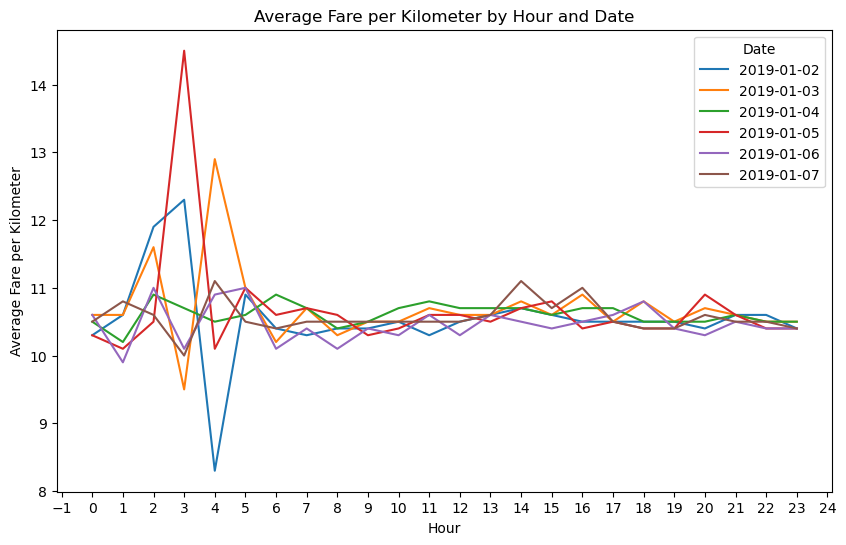

In [32]:
plt.figure(figsize=(10, 6))
for date in average_fare_per_km.columns:
    plt.plot(average_fare_per_km.index, average_fare_per_km[date], label=str(date))
    
plt.locator_params(axis='x', nbins=30) 

plt.xlabel('Hour')
plt.ylabel('Average Fare per Kilometer')

plt.title('Average Fare per Kilometer by Hour and Date')

plt.legend(title='Date')

plt.show()


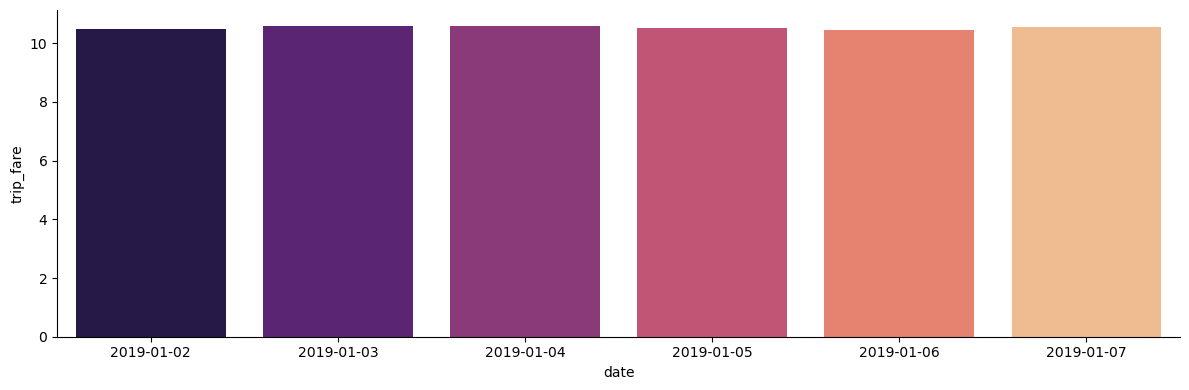

In [33]:
column_order = df['date'].value_counts().sort_index(ascending=True).index
aux_serie = round((df.groupby('date')['trip_fare'].sum()/df.groupby('date')['travel_distance'].sum()),2)                                                                                                                              
amount_km_df = pd.DataFrame(aux_serie)

amount_km_df = amount_km_df.reset_index()
amount_km_df.rename(columns={'date':'date',0:'trip_fare'},inplace=True)

sns.catplot(x='date', y='trip_fare', data=amount_km_df, kind='bar', height=4, aspect=3, order=column_order,palette='magma');

In [34]:
average = average_fare_per_km.mean().mean()
print("Average Fare per Kilometer:", average)

Average Fare per Kilometer: 10.59236111111111


***

### Longest and Costliest Ride Details

In [35]:
rides_distance = df[df.travel_distance==df.travel_distance.max()]
rides_distance

,trip_id,customer_id,timestamp,pick_lat,pick_lng,drop_lat,drop_lng,travel_distance,travel_time,trip_fare,date,hour,average_speed
7165,ID7166,CUST_1006,2019-01-06 21:23:45.616,17.443495,78.390411,17.444721,78.386597,52.801,14.1645,593,2019-01-06,21,223.661972


***

## Key Metric Calculation

Calculate the average duration between a customer's first and second trip (for customers with 2 or more trips).

***

In [36]:
customer_trip_counts = df['customer_id'].value_counts()

In [37]:
customers_with_multi_trip = customer_trip_counts[customer_trip_counts >= 2].index

In [38]:
df2 = df[df['customer_id'].isin(customers_with_multi_trip)]

In [39]:
sort_data = df2.sort_values(by=['customer_id', 'timestamp'])

In [40]:
group_data = sort_data.groupby('customer_id')

In [41]:
time_duration = []

In [42]:
for customer, group in group_data:
    first_trip_duration = group.iloc[0]['timestamp']
    second_trip_duration = group.iloc[1]['timestamp']
    duration = (second_trip_duration - first_trip_duration).total_seconds()
    time_duration.append(duration)

In [43]:
average_time_duration = (sum(time_duration) / len(time_duration))/60

In [44]:
average_time_duration=round(average_time_duration,2)

In [45]:
print("The average duration between the 1st trip and the 2nd trip of customers is:", average_time_duration, "minutes")

The average duration between the 1st trip and the 2nd trip of customers is: 1492.16 minutes


## Correlation Analysis

***

In [46]:
correlation_matrix = df.corr()

In [47]:
correlation_matrix

,pick_lat,pick_lng,drop_lat,drop_lng,travel_distance,travel_time,trip_fare,hour,average_speed
pick_lat,1.000000,-0.586615,0.558672,-0.525249,-0.000177,-0.009179,-0.001974,0.030741,-0.002217
pick_lng,-0.586615,1.000000,-0.418848,0.834099,-0.000829,0.003717,-0.001474,-0.036790,-0.000646
drop_lat,0.558672,-0.418848,1.000000,-0.400705,-0.001702,-0.005534,-0.001719,0.026608,0.002475
drop_lng,-0.525249,0.834099,-0.400705,1.000000,-0.003445,0.002678,-0.002301,-0.036419,0.000214
travel_distance,-0.000177,-0.000829,-0.001702,-0.003445,1.000000,0.371086,0.915520,-0.011302,0.012236
travel_time,-0.009179,0.003717,-0.005534,0.002678,0.371086,1.000000,0.354476,0.013277,-0.037493
trip_fare,-0.001974,-0.001474,-0.001719,-0.002301,0.915520,0.354476,1.000000,-0.009151,0.009496
hour,0.030741,-0.036790,0.026608,-0.036419,-0.011302,0.013277,-0.009151,1.000000,0.000465
average_speed,-0.002217,-0.000646,0.002475,0.000214,0.012236,-0.037493,0.009496,0.000465,1.000000


(array([0.5, 1.5, 2.5, 3.5, 4.5, 5.5, 6.5, 7.5, 8.5]),
 [Text(0.5, 0, 'pick_lat'),
  Text(1.5, 0, 'pick_lng'),
  Text(2.5, 0, 'drop_lat'),
  Text(3.5, 0, 'drop_lng'),
  Text(4.5, 0, 'travel_distance'),
  Text(5.5, 0, 'travel_time'),
  Text(6.5, 0, 'trip_fare'),
  Text(7.5, 0, 'hour'),
  Text(8.5, 0, 'average_speed')])

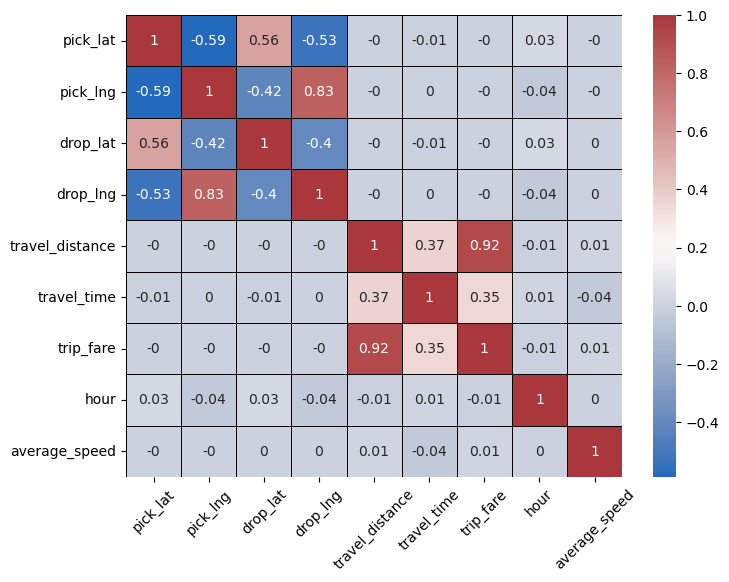

In [48]:
plt.figure(figsize=(8,6))
correlation_matrix = df.corr().round(2)

sns.heatmap(correlation_matrix, annot=True, cmap="vlag", linewidth=0.5, linecolor="black")
plt.xticks(rotation=45)

In [49]:
causation = correlation_matrix["trip_fare"].sort_values(ascending=False)

In [50]:
causation

trip_fare          1.00
travel_distance    0.92
travel_time        0.35
average_speed      0.01
pick_lat          -0.00
pick_lng          -0.00
drop_lat          -0.00
drop_lng          -0.00
hour              -0.01
Name: trip_fare, dtype: float64

## Top Geographical Clusters by Trip Volume

Identify the Top 5 pairs of H3 clusters (resolution=8) with the highest number of trips.

***

***

In [51]:
df['pick_hex'] = df.apply(lambda row: h3.geo_to_h3(row['pick_lat'], row['pick_lng'], 8), axis=1)
df['drop_hex'] = df.apply(lambda row: h3.geo_to_h3(row['drop_lat'], row['drop_lng'], 8), axis=1)

In [52]:
hex_pairs_count = df.groupby(['pick_hex', 'drop_hex']).size().reset_index(name='trip_count')

In [53]:
sorted_hex_pairs = hex_pairs_count.sort_values(by='trip_count', ascending=False)

In [54]:
top_5_hex_pairs = sorted_hex_pairs.head(5)
print("Rank  Hex pair (source_hexid, destination_hexid)    Total trips")

for i, row in top_5_hex_pairs.iterrows():
    print(f"{i+1}     {row['pick_hex']} to {row['drop_hex']}     {row['trip_count']}")

Rank  Hex pair (source_hexid, destination_hexid)    Total trips
8690     8860a259b9fffff to 8860a25995fffff     194
7918     8860a25995fffff to 8860a259b9fffff     90
8704     8860a259b9fffff to 8860a259bbfffff     82
8605     8860a259b9fffff to 8860a24a6dfffff     80
1106     8860a24a6dfffff to 8860a24b51fffff     79
